# A first TPU kernel

CPU companion; no accelerator is required. TPU execution not validated.

- Implement a real TPU-targeted Pallas launch with a broadcast BlockSpec.
- Specify target layout and float32 compute/output-cast policies.
- Verify CPU semantics across tails and precision choices.
- Refuse target execution claims when only interpretation is available.

An interpreted kernel can be numerically correct and still violate a TPU layout or compilation restriction. How do we build a genuine TPU launch path without pretending that a CPU test ran on an accelerator? We will implement a fused bias-and-ReLU kernel with separate, enforceable execution modes.

## The idea

The numerical contract is $Y_{ij}=\max(X_{ij}+b_j,0)$. A matrix tile and a column-bias window enter the kernel, and one output tile is written. CPU interpretation checks this behavior. The same target branch launches Pallas without interpretation only when actual TPU inputs and backend are present.

## Map each operand according to its meaning

The activation matrix has shape $(M,N)$; the bias has shape $(N,)$. We reshape the padded bias to $(1,N_p)$ and map its block coordinates to $(0,j)$, so changing the row-program index does not change the bias window. The output uses $(i,j)$ and is written exactly once per tile. This is intentional broadcasting with an explicit contract, unlike accepting accidentally mismatched matrices.

## Use a conservative TPU tile contract

TPU vector-memory layout places restrictions on block dimensions. This wrapper requires block dimensions that are multiples of $(8,128)$ for target mode, then pads and crops arbitrary positive logical shapes. The one-row bias window spans its whole first dimension. This is a deliberately narrow supported contract, not a claim that every other block shape is forbidden on every TPU generation. CPU interpretation alone does not enforce or validate all lowering restrictions.

## State where precision changes

Both inputs may be float32 or bfloat16, but their dtypes must match. The kernel promotes loaded values to float32 for addition and ReLU, then casts once to the output dtype. An independent reference must start from those same represented inputs and apply the same final cast. Comparing bfloat16 output directly to an unrounded original dataset mixes representation error with kernel correctness.

## Make the execution mode inspectable

The wrapper accepts only the strings interpret and tpu. The TPU branch checks the actual default backend and the devices holding the inputs, and passes interpret=False. It never catches a target lowering failure and retries on CPU. A target failure should remain a failed result with its environment, not become a fabricated successful accelerator receipt.

## Run the real target path as a separate lab

On an already configured TPU environment, use `python3 projects/kernel-audit/target_tpu.py --kernel fused --block 8 128`. That runner explicitly places inputs on a TPU, calls the target branch, synchronizes, and prints a JSON evidence record after numerical comparisons. Run it in a fresh TPU process rather than a CPU-forced lesson runner. The command is implemented; no target receipt exists in this authoring environment. CPU interpretation establishes neither target lowering success nor speedup.

## Compare with a strong baseline before optimizing

The ordinary JAX expression can already be fused by XLA. A hand-written fused kernel is not automatically faster. On the target, compare with a warmed jitted baseline using the same dtype, data, padding boundary and output semantics. The final lesson defines the measurement protocol and distinguishes kernel-only timing from end-to-end wrapper cost.

## Define separate interpreted and target-only launch modes

Create main.py for the first block, then append each block in order in your course CPU environment.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def fused_bias_relu(x,bias,block=(8,128),mode="interpret"):
    if x.ndim!=2 or bias.ndim!=1 or bias.shape[0]!=x.shape[1] or min(x.shape)<1:
        raise ValueError("x must be (M,N), bias must be (N,), and dimensions nonempty")
    if x.dtype!=bias.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 required")
    bm,bn=block
    if not isinstance(bm,int) or not isinstance(bn,int) or bm<1 or bn<1:
        raise ValueError("positive integer block sizes required")
    if mode not in ("interpret","tpu"):
        raise ValueError("mode must explicitly be interpret or tpu")
    if mode=="tpu":
        if jax.default_backend()!="tpu" or any(not isinstance(a,jax.core.Tracer) and any(d.platform!="tpu" for d in a.devices()) for a in (x,bias)):
            raise RuntimeError("Real TPU inputs/backend required; CPU fallback is disabled")
        if bm%8 or bn%128:
            raise ValueError("this TPU wrapper requires block multiples of (8,128)")
    m,n=x.shape;pm=(m+bm-1)//bm*bm;pn=(n+bn-1)//bn*bn
    px=jnp.pad(x,((0,pm-m),(0,pn-n)))
    pb=jnp.pad(bias,(0,pn-n))[None,:]
    def kernel(x_ref,bias_ref,out_ref):
        value=x_ref[...].astype(jnp.float32)+bias_ref[...].astype(jnp.float32)
        out_ref[...]=jnp.maximum(value,0).astype(out_ref.dtype)
    matrix_spec=pl.BlockSpec((bm,bn),lambda i,j:(i,j))
    bias_spec=pl.BlockSpec((1,bn),lambda i,j:(0,j))
    output=pl.pallas_call(kernel,
        out_shape=jax.ShapeDtypeStruct((pm,pn),x.dtype),
        grid=(pm//bm,pn//bn),in_specs=(matrix_spec,bias_spec),out_specs=matrix_spec,
        interpret=(mode=="interpret"),
        compiler_params=pltpu.CompilerParams(dimension_semantics=("parallel","parallel")))(px,pb)
    return output[:m,:n]

The launch path states its execution mode explicitly. TPU mode refuses non-TPU inputs and enforces a conservative target tile contract; interpretation remains a named testing mode.

## Execute the kernel semantics on CPU

Create main.py for the first block, then append each block in order in your course CPU environment.

In [2]:
x=jnp.linspace(-2,2,9*129,dtype=jnp.float32).reshape(9,129)
bias=jnp.linspace(-.3,.4,129,dtype=jnp.float32)
actual=fused_bias_relu(x,bias)
reference=np.maximum(np.asarray(x)+np.asarray(bias)[None,:],0)
np.testing.assert_allclose(actual,reference,rtol=1e-6,atol=1e-6)
assert actual.shape==(9,129)
print("Interpretation max error:",float(np.max(np.abs(np.asarray(actual)-reference))))
print("Zero fraction and endpoint:",float(np.mean(reference==0)),float(actual[-1,-1]))

Interpretation max error: 0.0
Zero fraction and endpoint: 0.48578811369509045 2.4000000953674316


The matrix and column bias use different BlockSpecs. The bias window is reused across row blocks, while each output tile has unique ownership.

## Prove the target path cannot silently claim CPU success

Create main.py for the first block, then append each block in order in your course CPU environment.

In [3]:
if jax.default_backend()=="cpu":
    rejected=False
    try:fused_bias_relu(x,bias,mode="tpu")
    except RuntimeError as error:
        rejected=True
        print("Expected target refusal:",error)
    assert rejected
else:
    print("Reference lesson is intended for CPU; target execution uses the separate project runner")

Expected target refusal: Real TPU inputs/backend required; CPU fallback is disabled


The registered lesson executes CPU interpretation only. On real TPU hardware the project runner explicitly chooses mode=tpu, synchronizes, compares against a reference, and records the actual device.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def fused_bias_relu(x,bias,block=(8,128),mode="interpret"):
    if x.ndim!=2 or bias.ndim!=1 or bias.shape[0]!=x.shape[1] or min(x.shape)<1:
        raise ValueError("x must be (M,N), bias must be (N,), and dimensions nonempty")
    if x.dtype!=bias.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 required")
    bm,bn=block
    if not isinstance(bm,int) or not isinstance(bn,int) or bm<1 or bn<1:
        raise ValueError("positive integer block sizes required")
    if mode not in ("interpret","tpu"):
        raise ValueError("mode must explicitly be interpret or tpu")
    if mode=="tpu":
        if jax.default_backend()!="tpu" or any(not isinstance(a,jax.core.Tracer) and any(d.platform!="tpu" for d in a.devices()) for a in (x,bias)):
            raise RuntimeError("Real TPU inputs/backend required; CPU fallback is disabled")
        if bm%8 or bn%128:
            raise ValueError("this TPU wrapper requires block multiples of (8,128)")
    m,n=x.shape;pm=(m+bm-1)//bm*bm;pn=(n+bn-1)//bn*bn
    px=jnp.pad(x,((0,pm-m),(0,pn-n)))
    pb=jnp.pad(bias,(0,pn-n))[None,:]
    def kernel(x_ref,bias_ref,out_ref):
        value=x_ref[...].astype(jnp.float32)+bias_ref[...].astype(jnp.float32)
        out_ref[...]=jnp.maximum(value,0).astype(out_ref.dtype)
    matrix_spec=pl.BlockSpec((bm,bn),lambda i,j:(i,j))
    bias_spec=pl.BlockSpec((1,bn),lambda i,j:(0,j))
    output=pl.pallas_call(kernel,
        out_shape=jax.ShapeDtypeStruct((pm,pn),x.dtype),
        grid=(pm//bm,pn//bn),in_specs=(matrix_spec,bias_spec),out_specs=matrix_spec,
        interpret=(mode=="interpret"),
        compiler_params=pltpu.CompilerParams(dimension_semantics=("parallel","parallel")))(px,pb)
    return output[:m,:n]

x=jnp.linspace(-2,2,9*129,dtype=jnp.float32).reshape(9,129)
bias=jnp.linspace(-.3,.4,129,dtype=jnp.float32)
actual=fused_bias_relu(x,bias)
reference=np.maximum(np.asarray(x)+np.asarray(bias)[None,:],0)
np.testing.assert_allclose(actual,reference,rtol=1e-6,atol=1e-6)
assert actual.shape==(9,129)
print("Interpretation max error:",float(np.max(np.abs(np.asarray(actual)-reference))))
print("Zero fraction and endpoint:",float(np.mean(reference==0)),float(actual[-1,-1]))

if jax.default_backend()=="cpu":
    rejected=False
    try:fused_bias_relu(x,bias,mode="tpu")
    except RuntimeError as error:
        rejected=True
        print("Expected target refusal:",error)
    assert rejected
else:
    print("Reference lesson is intended for CPU; target execution uses the separate project runner")

Interpretation max error: 0.0
Zero fraction and endpoint: 0.48578811369509045 2.4000000953674316
Expected target refusal: Real TPU inputs/backend required; CPU fallback is disabled


Expected: CPU interpretation agrees with NumPy, including the (9,129) tail. The final value is approximately 2.4. Requesting TPU mode on CPU raises an explicit refusal.

## Bias and ReLU alter the values, not the tile ownership contract

Predict: Where will the biased first and last rows cross the zero threshold?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={'kind':'line','x':list(range(129)),'xlabel':'logical column','ylabel':'output activation','series':[{'label':'first row, CPU interpretation','y':np.asarray(actual)[0].tolist()},{'label':'last row, CPU interpretation','y':np.asarray(actual)[-1].tolist()}]}

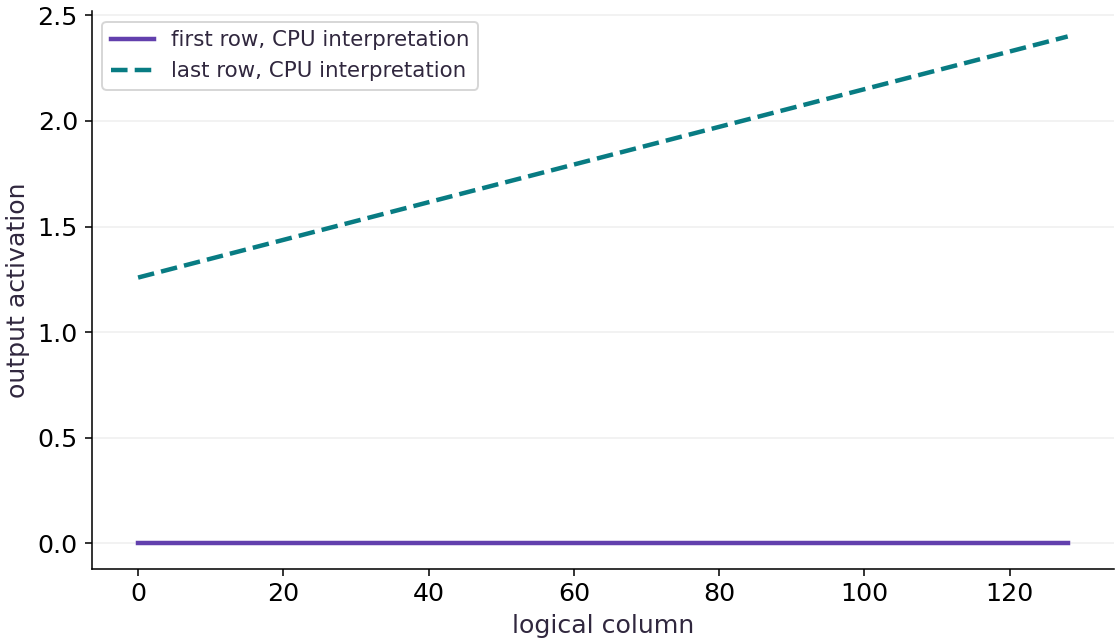

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is column index. The vertical axis is output activation after adding that column’s bias and applying ReLU. The two plotted series are the first and last rows from the actual interpreted $(9,129)$ kernel result.

The first row is entirely zero for this fixture because its negative activations remain below zero after bias. The last row stays positive and reaches approximately $2.4$ at column $128$, including the final partial logical tile. These are output values, not timings.

### Connect it to the computation

The per-column NumPy comparison verifies every element, while the displayed rows make the activation boundary and tail visible. The bias window depends on the column program index and is reused across row blocks.

This figure is labeled CPU interpretation. It does not prove TPU lowering, vector-memory scheduling or speed. The separate target-only runner refuses to create those claims without real TPU inputs and completed execution.

## Check the represented bfloat16 contract

Predict: Will bfloat16 inputs need comparison against their original float32 values or their rounded representations?

In [7]:
bx=x.astype(jnp.bfloat16);bb=bias.astype(jnp.bfloat16)
bactual=fused_bias_relu(bx,bb)
bref=jnp.maximum(bx.astype(jnp.float32)+bb.astype(jnp.float32)[None,:],0).astype(jnp.bfloat16)
np.testing.assert_array_equal(np.asarray(bactual),np.asarray(bref))
assert bactual.dtype==jnp.bfloat16
print("bfloat16 represented-input reference matched exactly")

bfloat16 represented-input reference matched exactly


Expected: The represented-input reference matches exactly for this fixture.

This checks the declared compute/cast policy. Any difference from the original float32 experiment is a separate precision-policy observation.

## Place the ReLU boundary deliberately

Predict: What should happen when a value exactly cancels its column bias?

In [8]:
edge_x=jnp.array([[-1.,0.,1.],[1.,-2.,.5]],dtype=jnp.float32)
edge_bias=jnp.array([1.,0.,-1.],dtype=jnp.float32)
edge=fused_bias_relu(edge_x,edge_bias)
np.testing.assert_array_equal(edge,np.array([[0.,0.,0.],[2.,0.,0.]],dtype=np.float32))
print("Boundary fixture:",np.asarray(edge))

Boundary fixture: [[0. 0. 0.]
 [2. 0. 0.]]


Expected: Exact cancellations become zero; the only positive result is 2.

Testing activation boundaries catches wrong bias axes and accidental operations applied before or after casting.

## Your exercise

Change the activation shape to (17,257), freeze a NumPy random seed and compare two target-compatible block choices in interpretation. Keep the bias values distinct by column.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
rng=np.random.default_rng(5)
changed_x=jnp.asarray(rng.normal(size=(17,257)),dtype=jnp.float32)
changed_bias=jnp.asarray(rng.normal(size=257),dtype=jnp.float32)
expected=np.maximum(np.asarray(changed_x)+np.asarray(changed_bias)[None,:],0)
for block in [(8,128),(16,256)]:
    result=fused_bias_relu(changed_x,changed_bias,block)
    np.testing.assert_allclose(result,expected,rtol=1e-6,atol=1e-6)
print("Changed tails and two TPU-compatible blocks verified in interpretation")

Changed tails and two TPU-compatible blocks verified in interpretation


## Reject hidden bias-axis broadcasting · Practice

Give the wrapper a matrix-shaped bias and then a wrong-length vector. Verify both fail before launch.

Hint: A column bias is a vector with exactly one entry per matrix column.

In [11]:
# Write your attempt here.

## Reference reasoning

Explicit validation turns a confusing broadcast result into a local contract error.

In [12]:
for malformed in (jnp.ones((1,129),dtype=jnp.float32),jnp.ones(9,dtype=jnp.float32)):
    rejected=False
    try:fused_bias_relu(x,malformed)
    except ValueError:rejected=True
    assert rejected
print("Malformed bias axes rejected")

Malformed bias axes rejected


## Check a permutation invariant · Challenge

Permute columns and bias entries together, then undo the permutation. Verify the output is unchanged.

Hint: Use a deterministic reversed column order; do not permute the bias independently.

In [13]:
# Write your attempt here.

## Reference reasoning

The kernel is columnwise when the corresponding bias travels with each column. This catches a wrong window map without relying only on one original fixture.

In [14]:
order=jnp.arange(128,-1,-1)
permuted=fused_bias_relu(x[:,order],bias[order])
np.testing.assert_allclose(permuted[:,order],actual,rtol=1e-6,atol=1e-6)
print("Column/bias pairing survives a joint permutation")

Column/bias pairing survives a joint permutation


## Checkpoint

What does a successful CPU interpret run establish for this target-oriented kernel?

1. The TPU kernel has measured high throughput.
2. The tested numerical Ref/grid semantics agree with the reference; target lowering and performance remain separate checks.
3. Every TPU generation accepts all block sizes.

## Diagnose

If every row has a repeated bias pattern, inspect the bias BlockSpec and its column coordinate. If CPU interpretation passes but TPU lowering fails, preserve the target error and inspect layout/dtype restrictions. If a target command succeeds on a CPU-only environment, its fallback guard is broken and the receipt must not be called TPU validation.

## Evidence

Broadcast/boundary checks, represented-input precision oracle and a tested no-fallback TPU guard; target execution remains separately unverified. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Map each operand according to its meaning
- Use a conservative TPU tile contract
- State where precision changes
- Make the execution mode inspectable
- Run the real target path as a separate lab
- Compare with a strong baseline before optimizing

## Primary references

- [Pallas grids and block specifications](https://docs.jax.dev/en/latest/pallas/grid_blockspec.html)
- [Writing TPU kernels: layout and memory restrictions](https://docs.jax.dev/en/latest/pallas/tpu/details.html)
- [TPU pipelining and emit_pipeline](https://docs.jax.dev/en/latest/pallas/tpu/pipelining.html)
- [TPU interpretation is simulation, not target execution](https://docs.jax.dev/en/latest/_autosummary/jax.experimental.pallas.tpu.InterpretParams.html)